In [1]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
from numpy.linalg import inv
import spherical as sph

In [2]:
ellipsoid = bl.WGS84
region = [-10,10,-10,10]
height = ellipsoid.mean_radius
coordinates = tuple(c.ravel() for c in vd.scatter_points(region, size=5000,extra_coords=height))
inclination, declination = -30, 20

In [3]:
# Syntetic Dipoles
dipole_coordinates = (np.array([-3]), np.array([3]), np.array([ellipsoid.mean_radius - 8e4]))
magnetic_field = sph.forward_modeling_spherical(coordinates,
    dipoles=dipole_coordinates,
    magnetic_moments=hm.magnetic_angles_to_vec(3e12, inclination, declination)
)
magnetic_anomaly = hm.total_field_anomaly(magnetic_field, inclination, declination)

dipole2_coordinates = (np.array([7]), np.array([-7]), np.array([ellipsoid.mean_radius - 9e4]))
magnetic_field = sph.forward_modeling_spherical(
    coordinates,
    dipoles=dipole2_coordinates,
    magnetic_moments=hm.magnetic_angles_to_vec(3e12, inclination, declination)
)
magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)

(np.float64(-10.99711708001059),
 np.float64(10.999278318779103),
 np.float64(-10.991213552800568),
 np.float64(10.996862625934378))

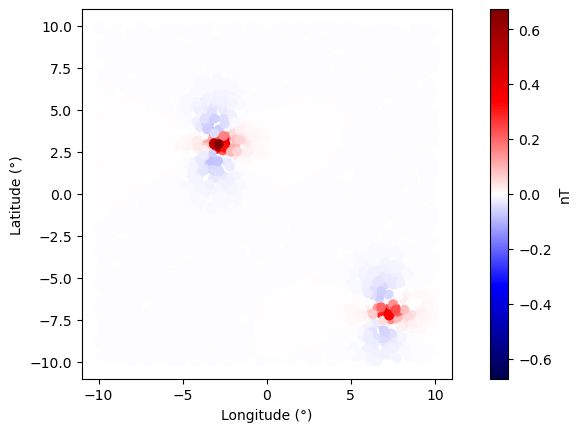

In [4]:
scale = vd.maxabs(magnetic_anomaly)
plt.scatter(coordinates[0], coordinates[1],  c = magnetic_anomaly, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

In [5]:
equivalent_layer = (
    coordinates[0],
    coordinates[1],
    coordinates[2] - 2e4
)



damping = 1e-20
eqs_inc = 90
eqs_dec = 0
eqs_dipole_unit = hm.magnetic_angles_to_vec(1,eqs_inc, eqs_dec)

In [6]:
window_size = 7
_, source_indices = vd.rolling_window(equivalent_layer, size=window_size, spacing=window_size / 2)
_, data_indices = vd.rolling_window(coordinates, size=window_size, spacing=window_size / 2)
source_indices = [i[0] for i in source_indices.ravel()]
data_indices = [i[0] for i in data_indices.ravel()]

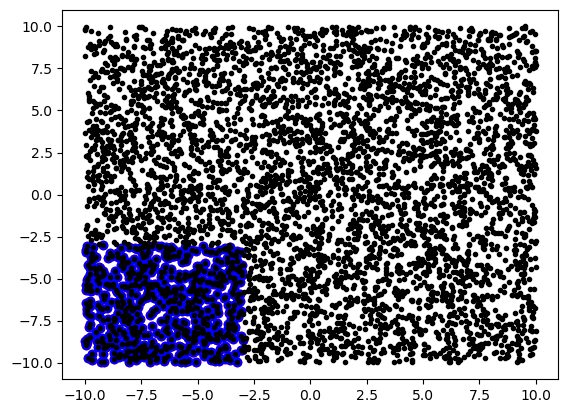

In [7]:
i = 0

data_coord = tuple(c[data_indices[i]] for c in coordinates)
source_coord = tuple(c[source_indices[i]] for c in equivalent_layer)

plt.plot(*data_coord[:2], "or")
plt.plot(*source_coord[:2], "ob")
plt.plot(*coordinates[:2], ".k")

In [8]:
def compute_magnetic_anomaly(grid_coord, inclination, declination, dipole_data, moment_amplitudes):
  
    moments = [
        hm.magnetic_angles_to_vec(amplitude, inclination, declination)
        for amplitude in moment_amplitudes
    ]

    grided_magnetic_anomaly = np.zeros(grid_coord[0].shape)

    for dipole_coordinates, moment in zip(dipole_data, moments):
        magnetic_field = sph.forward_modeling_spherical(
            grid_coord,
            dipoles=dipole_coordinates,
            magnetic_moments=moment
        )
        grided_magnetic_anomaly += hm.total_field_anomaly(magnetic_field, inclination, declination)
    
    return grided_magnetic_anomaly

In [9]:
grid_coord = tuple(c.ravel() for c in vd.grid_coordinates(region, shape=(150,150), extra_coords=ellipsoid.mean_radius + 200))

dipole_data = [dipole_coordinates, dipole2_coordinates]

grided_magnetic_anomaly = compute_magnetic_anomaly(grid_coord, inclination, declination, dipole_data, (3e12,3e12))

In [10]:
def fit(coordinates, data, eqs_source_coords, damping, eqs_inc, eqs_dec, inclination_main_field, declination_main_field):
    A = sph.jacobian(
        coordinates, 
        eqs_source_coords,
        eqs_inc, eqs_dec,
        inclination_main_field, declination_main_field
    )
    eqs_dipole_moment_amplitude = sph.calculate_coefficients(
        data, A, damping=damping,
    )
    return eqs_dipole_moment_amplitude

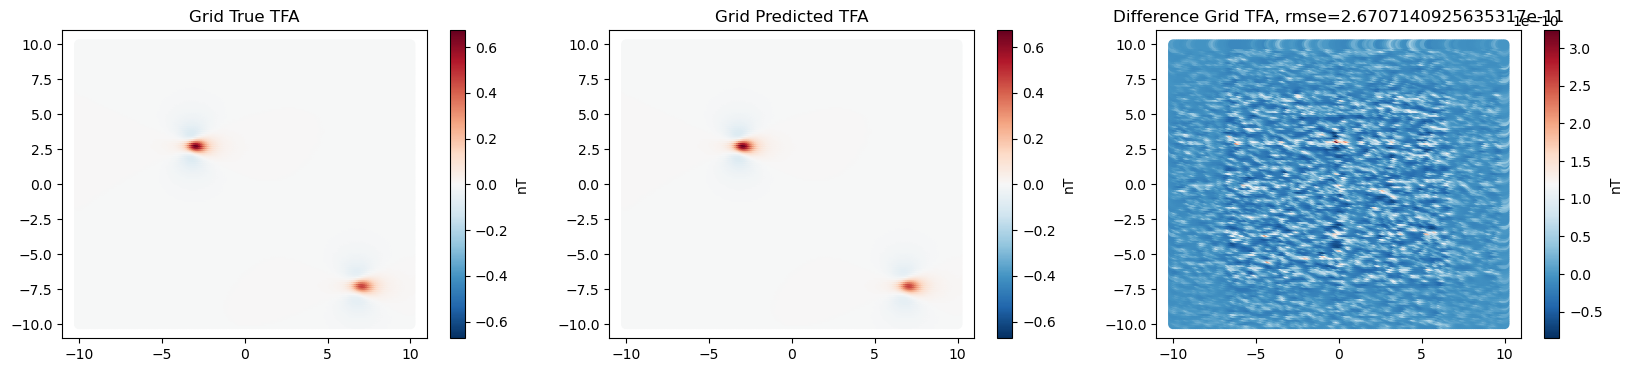

In [14]:
rmses = []
residuals = magnetic_anomaly.copy()
scale = vd.maxabs(magnetic_anomaly)
dipole_moment_amp = np.zeros_like(equivalent_layer[0])

predicted_total_field_grid = grided_magnetic_anomaly.copy()

window_indices = list(range(len(data_indices)))
np.random.shuffle(window_indices)
for i in window_indices:
    data_coord = tuple(c[data_indices[i]] for c in coordinates)
    source_coord = tuple(c[source_indices[i]] for c in equivalent_layer)
    
    eqs_dipole_moment_amp = fit(
        data_coord,
        residuals[data_indices[i]],
        source_coord,
        damping,
        eqs_inc,
        eqs_dec,
        inclination,
        declination
    )
    dipole_moment_amp[source_indices[i]] += eqs_dipole_moment_amp
    eqs_dipole_moment =  np.array( hm.magnetic_angles_to_vec(
    np.full(eqs_dipole_moment_amp.size, 1),  
    np.full(eqs_dipole_moment_amp.size, inclination),  
    np.full(eqs_dipole_moment_amp.size, declination)   
))


    predicted_total_field_anomaly = hm.total_field_anomaly(
        sph.forward_modeling_spherical(coordinates, source_coord, eqs_dipole_moment),
          inclination, declination)
    residuals -= predicted_total_field_anomaly
    
    
    predicted_total_field_grid -= hm.total_field_anomaly(
        sph.forward_modeling_spherical(grid_coord, source_coord, eqs_dipole_moment),
        inclination, declination,
    )

plt.figure(figsize=(20,4))
plt.subplot(1,3,1)
plt.title("Grid True TFA")
plt.scatter(
    *grid_coord[:2], c=grided_magnetic_anomaly, cmap="RdBu_r", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')
plt.subplot(1,3,2)
plt.title("Grid Predicted TFA")
plt.scatter(
    *grid_coord[:2], c=predicted_total_field_grid, cmap="RdBu_r", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')
diff_grid_tfa = grided_magnetic_anomaly - predicted_total_field_grid
rmse_grid_tfa = np.sqrt(np.square(diff_grid_tfa).mean())
plt.subplot(1,3,3)
plt.title('Difference Grid TFA, rmse={}'.format(rmse_grid_tfa))
plt.scatter(
    *grid_coord[:2], c=diff_grid_tfa, cmap="RdBu_r")
plt.colorbar(label='nT')